## Accessing DM-EFD data


In this notebook we demonstrate the LSST EFD client.
The client docs can be found [here](https://efd-client.lsst.io).

This is complementaty to the [Chronograf](https://lsst-chronograf-int-efd.ncsa.illinois.edu/) interface which we use for time-series visualization.

In [1]:
from astropy.time import Time, TimeDelta
from lsst_efd_client import EfdClient

We'll access the EFD instance deployed at the Summit.

In [5]:
client = EfdClient('summit_efd')

## Listing topics
Topics are mapped to [InfluxDB measurements](https://docs.influxdata.com/influxdb/v1.7/concepts/key_concepts/#measurement). The following query simply lists all topics in the InfluxDB `efd` database:

In [9]:
topics = await client.get_topics()
for topic in topics:
    items = topic.split('.')
    if items[2] == "CCCamera":
        print(topic)

lsst.sal.CCCamera.ackcmd
lsst.sal.CCCamera.command_disable
lsst.sal.CCCamera.command_enable
lsst.sal.CCCamera.command_enterControl
lsst.sal.CCCamera.command_exitControl
lsst.sal.CCCamera.command_standby
lsst.sal.CCCamera.command_start
lsst.sal.CCCamera.command_takeImages
lsst.sal.CCCamera.logevent_appliedSettingsMatchStart
lsst.sal.CCCamera.logevent_availableFilters
lsst.sal.CCCamera.logevent_ccsCommandState
lsst.sal.CCCamera.logevent_endOfImageTelemetry
lsst.sal.CCCamera.logevent_endReadout
lsst.sal.CCCamera.logevent_focalPlaneHardwareIdSettingsApplied
lsst.sal.CCCamera.logevent_focalPlaneSummaryInfo
lsst.sal.CCCamera.logevent_heartbeat
lsst.sal.CCCamera.logevent_imageReadinessDetailedState
lsst.sal.CCCamera.logevent_imageReadoutParameters
lsst.sal.CCCamera.logevent_offlineDetailedState
lsst.sal.CCCamera.logevent_raftsDetailedState
lsst.sal.CCCamera.logevent_settingVersions
lsst.sal.CCCamera.logevent_settingsApplied
lsst.sal.CCCamera.logevent_softwareVersions
lsst.sal.CCCamera.logeven

## Querying topic data

In [26]:
t1 = Time('2021-01-11T16:00:00', scale='tai')
t2 = t1 + TimeDelta(10*3600, format='sec', scale='tai')

In [35]:
df = await client.select_time_series('lsst.sal.CCCamera.logevent_endOfImageTelemetry', '*', t1, t2)
df

,additionalKeys,additionalValues,darkTime,exposureTime,imageController,imageDate,imageIndex,imageName,imageNumber,imageSource,...,private_identity,private_kafkaStamp,private_origin,private_rcvStamp,private_revCode,private_seqNum,private_sndStamp,timestampAcquisitionStart,timestampDateEnd,timestampDateObs
2021-01-11 19:26:03.862000+00:00,imageType:groupId:testType,BIAS:CALSET_20210111_1925:BIAS,0.112257,0,O,20210111,0,CC_O_20210111_000001,1,CC,...,CCCamera,1.610393e+09,40318596,1.610393e+09,09c0cceb,0,1.610393e+09,1.610393e+09,1.610393e+09,1.610393e+09
2021-01-11 22:41:09.734000+00:00,imageType:groupId:testType,BIAS:CALSET_20210111_2240:BIAS,0.107436,0,O,20210111,0,CC_O_20210111_000002,2,CC,...,CCCamera,1.610405e+09,40318596,1.610405e+09,09c0cceb,1,1.610405e+09,1.610405e+09,1.610405e+09,1.610405e+09
2021-01-11 22:55:44.814000+00:00,imageType:groupId:testType,BIAS:CALSET_20210111_2255:BIAS,0.105961,0,O,20210111,0,CC_O_20210111_000003,3,CC,...,CCCamera,1.610406e+09,40318596,1.610406e+09,09c0cceb,2,1.610406e+09,1.610406e+09,1.610406e+09,1.610406e+09
2021-01-11 23:03:08.453000+00:00,imageType:groupId:testType,BIAS:CALSET_20210111_2302:BIAS,0.101394,0,O,20210111,0,CC_O_20210111_000004,4,CC,...,CCCamera,1.610406e+09,40318596,1.610406e+09,09c0cceb,3,1.610406e+09,1.610406e+09,1.610406e+09,1.610406e+09
2021-01-11 23:03:16.156000+00:00,imageType:groupId:testType,BIAS:CALSET_20210111_2302:BIAS,0.099018,0,O,20210111,0,CC_O_20210111_000005,5,CC,...,CCCamera,1.610406e+09,40318596,1.610406e+09,09c0cceb,4,1.610406e+09,1.610406e+09,1.610406e+09,1.610406e+09
2021-01-11 23:03:23.880000+00:00,imageType:groupId:testType,BIAS:CALSET_20210111_2302:BIAS,0.114137,0,O,20210111,0,CC_O_20210111_000006,6,CC,...,CCCamera,1.610406e+09,40318596,1.610406e+09,09c0cceb,5,1.610406e+09,1.610406e+09,1.610406e+09,1.610406e+09
2021-01-11 23:03:31.584000+00:00,imageType:groupId:testType,BIAS:CALSET_20210111_2302:BIAS,0.104867,0,O,20210111,0,CC_O_20210111_000007,7,CC,...,CCCamera,1.610406e+09,40318596,1.610406e+09,09c0cceb,6,1.610406e+09,1.610406e+09,1.610406e+09,1.610406e+09
2021-01-11 23:03:39.066000+00:00,imageType:groupId:testType,BIAS:CALSET_20210111_2302:BIAS,0.100638,0,O,20210111,0,CC_O_20210111_000008,8,CC,...,CCCamera,1.610406e+09,40318596,1.610406e+09,09c0cceb,7,1.610406e+09,1.610406e+09,1.610406e+09,1.610406e+09


In [9]:
topics = await client.get_topics()
for topic in topics:
    items = topic.split('.')
    if items[2] == "CCCamera":
        print(topic)

lsst.sal.CCCamera.ackcmd
lsst.sal.CCCamera.command_disable
lsst.sal.CCCamera.command_enable
lsst.sal.CCCamera.command_enterControl
lsst.sal.CCCamera.command_exitControl
lsst.sal.CCCamera.command_standby
lsst.sal.CCCamera.command_start
lsst.sal.CCCamera.command_takeImages
lsst.sal.CCCamera.logevent_appliedSettingsMatchStart
lsst.sal.CCCamera.logevent_availableFilters
lsst.sal.CCCamera.logevent_ccsCommandState
lsst.sal.CCCamera.logevent_endOfImageTelemetry
lsst.sal.CCCamera.logevent_endReadout
lsst.sal.CCCamera.logevent_focalPlaneHardwareIdSettingsApplied
lsst.sal.CCCamera.logevent_focalPlaneSummaryInfo
lsst.sal.CCCamera.logevent_heartbeat
lsst.sal.CCCamera.logevent_imageReadinessDetailedState
lsst.sal.CCCamera.logevent_imageReadoutParameters
lsst.sal.CCCamera.logevent_offlineDetailedState
lsst.sal.CCCamera.logevent_raftsDetailedState
lsst.sal.CCCamera.logevent_settingVersions
lsst.sal.CCCamera.logevent_settingsApplied
lsst.sal.CCCamera.logevent_softwareVersions
lsst.sal.CCCamera.logeven

In [38]:
print(type(df))

<class 'pandas.core.frame.DataFrame'>


In [41]:
df.columns

Index(['additionalKeys', 'additionalValues', 'darkTime', 'exposureTime',
       'imageController', 'imageDate', 'imageIndex', 'imageName',
       'imageNumber', 'imageSource', 'imageTag', 'imagesInSequence',
       'measuredShutterOpenTime', 'priority', 'private_host',
       'private_identity', 'private_kafkaStamp', 'private_origin',
       'private_rcvStamp', 'private_revCode', 'private_seqNum',
       'private_sndStamp', 'timestampAcquisitionStart', 'timestampDateEnd',
       'timestampDateObs'],
      dtype='object')

In [54]:
times = df['timestampDateObs'].tolist()
print(times)
for time in times:
    print("EFD-TAI:",Time(time, format="unix", scale='tai').isot, "\t EFD-UTC:",Time(time, format="unix", scale='utc').isot)

[1610393161.040603, 1610404866.9098678, 1610405742.0429285, 1610406185.6010323, 1610406193.3265774, 1610406201.0469697, 1610406208.7544155, 1610406216.465249]
EFD-TAI: 2021-01-11T19:26:38.041 	 EFD-UTC: 2021-01-11T19:26:01.041
EFD-TAI: 2021-01-11T22:41:43.910 	 EFD-UTC: 2021-01-11T22:41:06.910
EFD-TAI: 2021-01-11T22:56:19.043 	 EFD-UTC: 2021-01-11T22:55:42.043
EFD-TAI: 2021-01-11T23:03:42.601 	 EFD-UTC: 2021-01-11T23:03:05.601
EFD-TAI: 2021-01-11T23:03:50.327 	 EFD-UTC: 2021-01-11T23:03:13.327
EFD-TAI: 2021-01-11T23:03:58.047 	 EFD-UTC: 2021-01-11T23:03:21.047
EFD-TAI: 2021-01-11T23:04:05.754 	 EFD-UTC: 2021-01-11T23:03:28.754
EFD-TAI: 2021-01-11T23:04:13.465 	 EFD-UTC: 2021-01-11T23:03:36.465


In [48]:
topics = await client.get_topics()
for topic in topics:
    items = topic.split('.')
    if items[2] == "ATCamera":
        print(topic)

lsst.sal.ATCamera.ackcmd
lsst.sal.ATCamera.command_clear
lsst.sal.ATCamera.command_disable
lsst.sal.ATCamera.command_disableCalibration
lsst.sal.ATCamera.command_enable
lsst.sal.ATCamera.command_enableCalibration
lsst.sal.ATCamera.command_endImage
lsst.sal.ATCamera.command_enterControl
lsst.sal.ATCamera.command_exitControl
lsst.sal.ATCamera.command_initImage
lsst.sal.ATCamera.command_standby
lsst.sal.ATCamera.command_start
lsst.sal.ATCamera.command_takeImages
lsst.sal.ATCamera.fp_Ccd
lsst.sal.ATCamera.fp_Reb
lsst.sal.ATCamera.fp_RebTotalPower
lsst.sal.ATCamera.logevent_appliedSettingsMatchStart
lsst.sal.ATCamera.logevent_calibrationDetailedState
lsst.sal.ATCamera.logevent_ccsCommandState
lsst.sal.ATCamera.logevent_endOfImageTelemetry
lsst.sal.ATCamera.logevent_endReadout
lsst.sal.ATCamera.logevent_endShutterClose
lsst.sal.ATCamera.logevent_endShutterOpen
lsst.sal.ATCamera.logevent_heartbeat
lsst.sal.ATCamera.logevent_imageReadinessDetailedState
lsst.sal.ATCamera.logevent_offlineDetaile

In [31]:
df = await client.select_time_series('lsst.sal.ATCamera.vacuum', '*', t1, t2)
df.head()

,private_host,private_identity,private_kafkaStamp,private_origin,private_rcvStamp,private_revCode,private_seqNum,private_sndStamp,tempCCD,tempCCDSetPoint,tempColdPlate,tempCryoHead,vacuum
2021-01-11 16:00:03.030000+00:00,0,ATCamera,1.610381e+09,64206792,1.610381e+09,35a37492,22029,1.610381e+09,-94.144096,-94.150002,-115.139099,-140.759094,2.950000e-07
2021-01-11 16:00:13.015000+00:00,0,ATCamera,1.610381e+09,64206792,1.610381e+09,35a37492,22030,1.610381e+09,-94.142799,-94.150002,-115.137199,-140.756195,2.940000e-07
2021-01-11 16:00:23.016000+00:00,0,ATCamera,1.610381e+09,64206792,1.610381e+09,35a37492,22031,1.610381e+09,-94.141197,-94.150002,-115.135399,-140.754700,2.940000e-07
2021-01-11 16:00:33.001000+00:00,0,ATCamera,1.610381e+09,64206792,1.610381e+09,35a37492,22032,1.610381e+09,-94.141998,-94.150002,-115.134003,-140.750000,2.930000e-07
2021-01-11 16:00:43.048000+00:00,0,ATCamera,1.610381e+09,64206792,1.610381e+09,35a37492,22033,1.610381e+09,-94.145103,-94.150002,-115.132103,-140.748993,2.930000e-07


At this point you can use [Pandas](https://pandas.pydata.org/pandas-docs/stable/reference/index.html) to analyze the data. First plot all CCD temperature data at full resolution.

<AxesSubplot:>

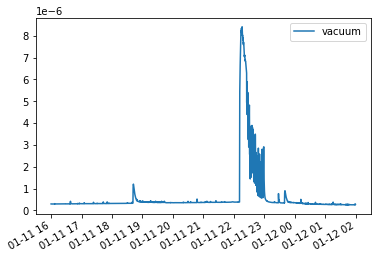

In [32]:
df.plot(y='vacuum')

Now average data over 15 minute intervals and plot.

In [33]:
Vac01 = df['vacuum'].resample('15min').mean()

<AxesSubplot:>

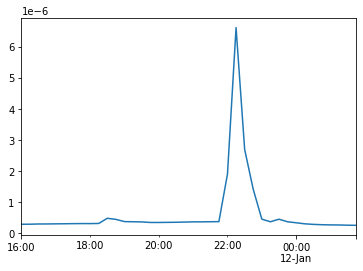

In [34]:
Vac01.plot()

Finally, we can look at correlations between values in the database.

In [ ]:
df.plot.scatter(x='temp1', y='temp2')

## Querying annotations

In Chronograf, you can annotate the time-series to mark interesting events or features in the data. These annotations are saved in the `chronograf` database and can also be queried.

In [ ]:
df = await client.influx_client.query('SELECT * FROM "chronograf"."autogen"."annotations"')
df['text']